In [11]:
import os
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from scipy.integrate import quad
import matplotlib.pyplot as plt
from labmate.acquisition_notebook import AcquisitionAnalysisManager

In [12]:
from utils.plot_style import set_plot_style 
set_plot_style()

# Reflectivity measurements of mirrors

### Load data

In [59]:
path_folder_data = r'./data/data_pm100a/reflectivity_laseroptik_T004Q2 05 19'
# path_folder_data = r'./data/data_pm100a/reflectivity/2026-05-20_metallic_unknown_001'
# path_folder_data = r'./data/data_pm100a/transmitivity/2026-05-20_laseroptik-T004Q2_002'
folder_data_files = os.listdir(path_folder_data)
print(folder_data_files)

['pm100a', 'temp.json']


In [60]:
name_exp = "pm100a"
# name_exp = "reflectivity_metallic_unknown"
# name_exp = "transmitivity_laseroptik-T004Q2"
folder_data_files = os.listdir(path_folder_data + "/" + name_exp)
print(folder_data_files)

['2026_05_19__15_03_03__pm100a.h5', '2026_05_19__15_03_24__pm100a.h5', '2026_05_19__15_03_46__pm100a.h5', '2026_05_19__15_04_00__pm100a.h5', '2026_05_19__15_04_19__pm100a.h5', '2026_05_19__15_04_32__pm100a.h5', '2026_05_19__15_04_56__pm100a.h5', '2026_05_19__15_05_08__pm100a.h5', '2026_05_19__15_05_30__pm100a.h5', '2026_05_19__15_05_43__pm100a.h5']


The file are individual records. But the measurements was:
- first in front of mirror
- second behind mirror

So first file of folder is front, second is back, then we switch the power input, 3rd is front, 4th is back, and so on. We plot the transmitted power VS the input power from the h5 files.

In [61]:
aqm = AcquisitionAnalysisManager(os.path.join(path_folder_data, name_exp))

P_in = []
P_in_error = []
P_tr = []
P_tr_error = []

for f_front, f_back in zip(folder_data_files[0::2], folder_data_files[1::2]):

    aqm.analysis_cell(filename=os.path.join(path_folder_data, name_exp, f_front))
    P_front = aqm.data["mean_mW"]
    P_front_error = aqm.data["error_mW"]

    aqm.analysis_cell(filename=os.path.join(path_folder_data, name_exp, f_back))
    P_back = aqm.data["mean_mW"]
    P_back_error = aqm.data["error_mW"]

    P_in.append(P_front)
    P_in_error.append(P_front_error)
    P_tr.append(P_back)
    P_tr_error.append(P_back_error)

INFO:2026_05_19__15_03_03__pm100a


INFO:2026_05_19__15_03_24__pm100a


INFO:2026_05_19__15_03_46__pm100a


INFO:2026_05_19__15_04_00__pm100a


INFO:2026_05_19__15_04_19__pm100a


INFO:2026_05_19__15_04_32__pm100a


INFO:2026_05_19__15_04_56__pm100a


INFO:2026_05_19__15_05_08__pm100a


INFO:2026_05_19__15_05_30__pm100a


INFO:2026_05_19__15_05_43__pm100a


In [62]:
# Incident power
P_in = np.array(P_in)
P_in_error = np.array(P_in_error)

# Transmitted power (or reflected power depending on what measurement is done)
P_tr = np.array(P_tr)
P_tr_error = np.array(P_tr_error)

In [63]:
# Check arrays
print("Power in (mW): ", P_in, "Error: ", P_in_error)
print("Power transmitted/reflected (mW): ", P_tr, "Error: ", P_tr_error)

Power in (mW):  [ 23.79167135  50.356536    76.98928417  99.72787424 120.84851905] Error:  [0.01509309 0.0175636  0.02816989 0.02413427 0.02692985]
Power transmitted/reflected (mW):  [ 20.91579382  44.01951749  66.53799191  87.03223951 105.94968975] Error:  [0.019128   0.01954288 0.02104776 0.02967088 0.02128805]


In [55]:
def linear(x, T, offset):
    return T*x + offset

In [64]:
# Fit for transmitted power
popt, pcov = curve_fit(linear, P_in, P_tr)
T, offset = popt
T_err, offset_err = np.sqrt(np.diag(pcov))

R = 1 - T
R_err = T_err

xfit = np.linspace(0, 1.05*np.max(P_in), 300)

In [ ]:
# Fit for reflected power

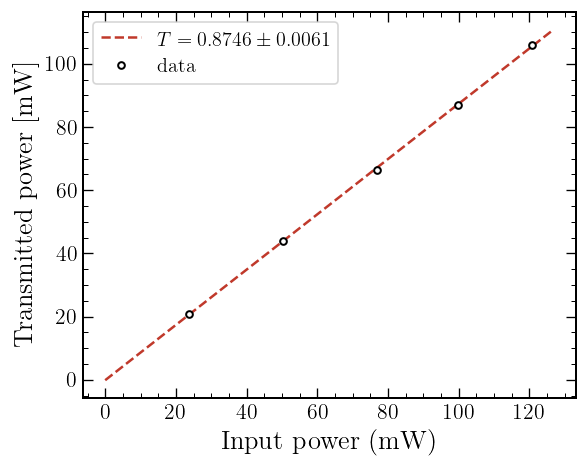

Transmission coefficient T = 0.874609 ± 0.006106
Reflectivity coefficient R = 1 - T = 0.125391 ± 0.006106
Fit offset = -0.130 ± 0.500 mW


In [ ]:
# Plotting
plt.figure(figsize=(5, 4))

plt.plot(xfit, linear(xfit, *popt),
    "--",
    color="#C0392B",
    # color="#2E86AB",
    linewidth=1.5,
    # label=rf"$R={T:.4f}\pm{T_err:.4f}$") # Switch commented line depending on what is plotted
    label=rf"$T={T:.4f}\pm{T_err:.4f}$")

plt.plot(P_in, P_tr,
    "o",
    color="black",
    markersize=4,
    markerfacecolor="white",
    markeredgewidth=1.2,
    label="data")

plt.xlabel("Input power (mW)")
plt.ylabel("Transmitted power (mW)") # Switch commented line depending on what is plotted
# plt.ylabel("Reflected Power (mW)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Transmission coefficient T = {T:.6f} ± {T_err:.6f}")
print(f"Reflectivity coefficient R = 1 - T = {R:.6f} ± {R_err:.6f}")
print(f"Fit offset = {offset:.3f} ± {offset_err:.3f} mW")